# DCGAN - Face Generation com CelebA

Neste notebook, vamos implementar um **DCGAN (Deep Convolutional GAN)** para gerar faces realistas usando o dataset CelebA.

## O que é DCGAN?
DCGAN é uma arquitetura que combina CNNs com GANs usando convoluções transpostas no gerador e convoluções normais no discriminador, resultando em geração de imagens de alta qualidade.

**Referência:** Radford et al., 2015 - "Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks"

## 1. Imports e Configurações

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import requests
import shutil
from tqdm import tqdm
import seaborn as sns
import json

# Configurações
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Usando dispositivo: {device}')

# Seeds para reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

print('✅ Imports concluídos!')

🖥️ Usando dispositivo: cuda
✅ Imports concluídos!


## 2. Download e Preparação dos Dados

### 2.1 Download + Unzip + Listar arquivos

In [2]:
# URL do dataset
url = "https://s3.amazonaws.com/video.udacity-data.com/topher/2018/November/5be7eb6f_processed-celeba-small/processed-celeba-small.zip"

# Caminhos
zip_path = "/kaggle/working/processed-celeba-small.zip"
extract_path = "/kaggle/working/"
extract_folder = os.path.join(extract_path, "processed_celeba_small")

# =========================================================
# DOWNLOAD
# =========================================================
if not os.path.exists(zip_path):
    print("📥 Baixando dataset...")
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get("content-length", 0))
    with open(zip_path, "wb") as file, tqdm(
        desc="Download",
        total=total_size,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)
    print("✅ Download concluído!")
else:
    print("✅ ZIP já existe.")

# =========================================================
# EXTRAIR ZIP
# =========================================================
if not os.path.exists(extract_folder):
    print("📦 Extraindo dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Extração concluída!")
else:
    print("✅ Dataset já extraído.")

# =========================================================
# LISTAR ARQUIVOS
# =========================================================
print("\n📂 Estrutura do dataset:\n")
for root, dirs, files in os.walk(extract_folder):
    level = root.replace(extract_folder, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}📁 {os.path.basename(root)}")
    subindent = " " * 4 * (level + 1)
    for file in files[:5]:
        print(f"{subindent}📄 {file}")
    if len(files) > 5:
        print(f"{subindent}... (+{len(files)-5} arquivos)")
    if level > 1:  # Limitar profundidade
        break

📥 Baixando dataset...


Download: 100%|██████████| 236M/236M [00:05<00:00, 42.6MB/s]


✅ Download concluído!
📦 Extraindo dataset...
✅ Extração concluída!

📂 Estrutura do dataset:

📁 processed_celeba_small
    📄 .DS_Store
    📁 celeba
        📄 171667.jpg
        📄 172633.jpg
        📄 169295.jpg
        📄 174354.jpg
        📄 166525.jpg
        ... (+32596 arquivos)
        📁 New Folder With Items
            📄 011404.jpg
            📄 025663.jpg
            📄 053179.jpg
            📄 020004.jpg
            📄 056753.jpg
            ... (+57326 arquivos)


### 2.2 Juntar todas as imagens em uma única pasta

In [3]:
source_root = "/kaggle/working/processed_celeba_small/celeba"
target_dir = "/kaggle/working/all_faces"

os.makedirs(target_dir, exist_ok=True)

moved = 0

for root, dirs, files in os.walk(source_root):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            src = os.path.join(root, file)
            dst = os.path.join(target_dir, file)
            
            # evita sobrescrever
            if not os.path.exists(dst):
                shutil.move(src, dst)
                moved += 1

print(f"✅ {moved} imagens movidas para:")
print(target_dir)

# mostrar quantidade final
total = len(os.listdir(target_dir))
print(f"\n📸 Total de imagens: {total}")

# mostrar algumas imagens
print("\n🖼️ Exemplos:")
print(os.listdir(target_dir)[:10])

✅ 89931 imagens movidas para:
/kaggle/working/all_faces

📸 Total de imagens: 89931

🖼️ Exemplos:
['011404.jpg', '171667.jpg', '025663.jpg', '053179.jpg', '172633.jpg', '169295.jpg', '174354.jpg', '020004.jpg', '056753.jpg', '055367.jpg']


### 2.3 Criar estrutura correta para PyTorch ImageFolder

In [4]:
source_dir = "/kaggle/working/all_faces"

# estrutura esperada:
# faces_dataset/
#    faces/
target_root = "/kaggle/working/faces_dataset"
target_dir = os.path.join(target_root, "faces")

os.makedirs(target_dir, exist_ok=True)

copied = 0

for file in os.listdir(source_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        src = os.path.join(source_dir, file)
        dst = os.path.join(target_dir, file)
        
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            copied += 1

print("✅ Estrutura criada com sucesso!")
print("📂 Pasta root:", target_root)
print("📂 Pasta classe:", target_dir)
print("📸 Imagens copiadas:", len(os.listdir(target_dir)))

✅ Estrutura criada com sucesso!
📂 Pasta root: /kaggle/working/faces_dataset
📂 Pasta classe: /kaggle/working/faces_dataset/faces
📸 Imagens copiadas: 89931


### 2.4 Carregar dataset com DataLoader

In [5]:
# Hiperparâmetros
batch_size = 128
img_size = 64
nz = 100  # Dimensão do vetor latente

# Transform para normalizar em [-1, 1] (importante para DCGAN com Tanh)
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

dataset = datasets.ImageFolder(
    root="/kaggle/working/faces_dataset",
    transform=transform
)

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

dataset_size = len(dataset)

print("✅ Dataset carregado com sucesso!")
print(f"📸 Total de imagens: {dataset_size}")
print(f"📊 Número de batches: {len(train_loader)}")
print(f"🏷️ Classes: {dataset.classes}")
print(f"\n⚙️ Configurações:")
print(f"   Batch Size: {batch_size}")
print(f"   Image Size: {img_size}x{img_size}")
print(f"   Latent Dim: {nz}")

✅ Dataset carregado com sucesso!
📸 Total de imagens: 89931
📊 Número de batches: 703
🏷️ Classes: ['faces']

⚙️ Configurações:
   Batch Size: 128
   Image Size: 64x64
   Latent Dim: 100


### 2.5 Visualizar batch do DataLoader

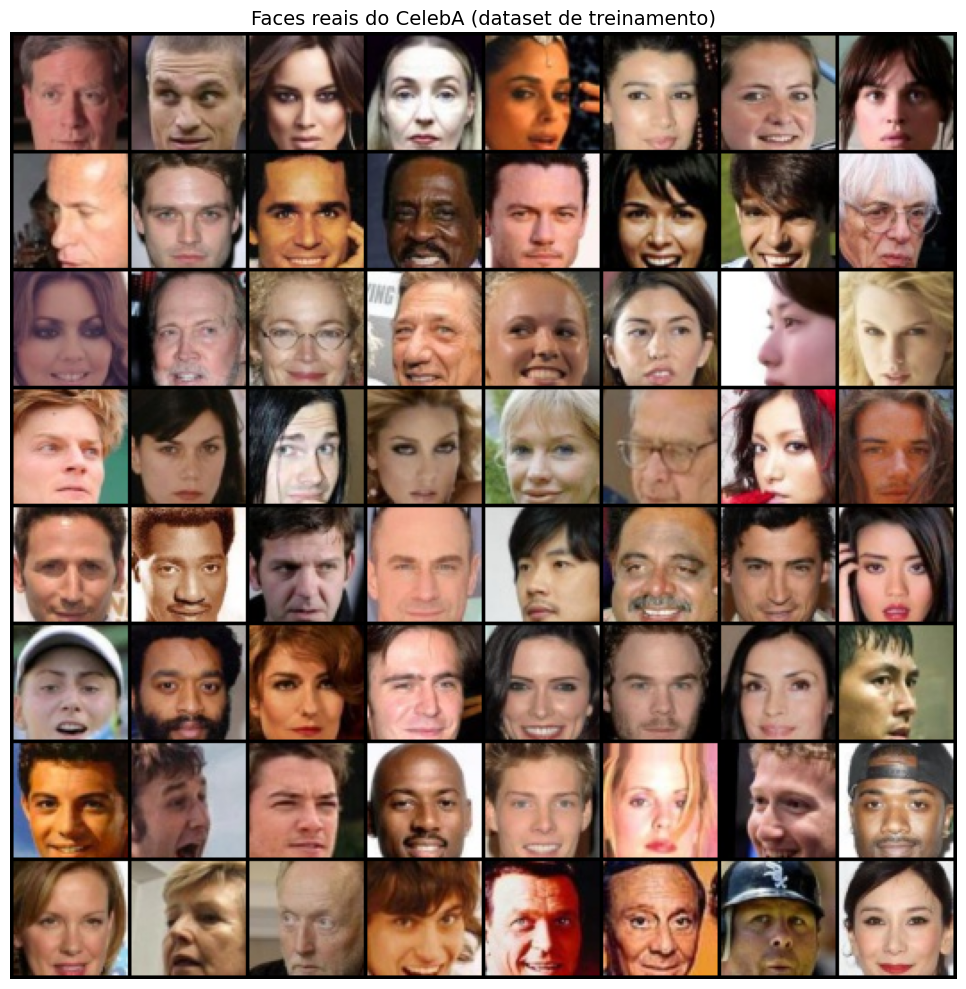

✅ Batch visualizado!
   Shape: torch.Size([128, 3, 64, 64])
   Imagens: 128, Canais: 3, Tamanho: 64x64


In [6]:
import torchvision

real_batch = next(iter(train_loader))

plt.figure(figsize=(10, 10))

grid = torchvision.utils.make_grid(
    real_batch[0][:64],
    padding=2,
    normalize=True
)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Faces reais do CelebA (dataset de treinamento)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"✅ Batch visualizado!")
print(f"   Shape: {real_batch[0].shape}")
print(f"   Imagens: {real_batch[0].shape[0]}, Canais: {real_batch[0].shape[1]}, Tamanho: {real_batch[0].shape[2]}x{real_batch[0].shape[3]}")

## 3. Arquitetura DCGAN

### 3.1 Gerador (Generator)

Transforma um vetor de ruído aleatório em uma imagem realista.

In [7]:
class Generator(nn.Module):
    """
    Gerador DCGAN.
    
    Arquitetura:
    - Entrada: vetor de ruído (nz,) onde nz é a dimensão latente
    - Saída: imagem RGB (3, 64, 64)
    
    Usa ConvTranspose2d (transposed convolutions) para upsampling.
    """
    def __init__(self, nz=100, ngf=64, nc=3):
        """
        Args:
            nz: dimensão do vetor latente (ruído)
            ngf: número de canais no gerador (base, aumenta em camadas anteriores)
            nc: número de canais da imagem (3 para RGB)
        """
        super(Generator, self).__init__()
        self.nz = nz
        
        # Primeira camada: linear + reshape
        # nz -> 64 * 8 * 4 * 4 (isso vai ser o tamanho antes das convoluções)
        self.fc = nn.Linear(nz, ngf * 8 * 4 * 4)
        
        self.main = nn.Sequential(
            # Estado: (ngf*8, 4, 4) = (512, 4, 4)
            nn.ConvTranspose2d(ngf * 8, ngf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # Estado: (ngf*4, 8, 8) = (256, 8, 8)
            
            nn.ConvTranspose2d(ngf * 4, ngf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # Estado: (ngf*2, 16, 16) = (128, 16, 16)
            
            nn.ConvTranspose2d(ngf * 2, ngf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # Estado: (ngf, 32, 32) = (64, 32, 32)
            
            nn.ConvTranspose2d(ngf, nc, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),  # Saída em [-1, 1]
            # Estado final: (3, 64, 64)
        )
    
    def forward(self, z):
        # z: (batch_size, nz)
        x = self.fc(z)
        x = x.view(x.size(0), -1, 4, 4)  # Reshape para (batch_size, ngf*8, 4, 4)
        x = self.main(x)
        return x

# Criar e testar gerador
gen = Generator(nz=nz).to(device)
print("🎨 Gerador criado:")
print(gen)

# Teste forward pass
z_test = torch.randn(4, nz).to(device)
fake_images = gen(z_test)
print(f'\n✅ Output shape: {fake_images.shape}')  # Esperado: (4, 3, 64, 64)

🎨 Gerador criado:
Generator(
  (fc): Linear(in_features=100, out_features=8192, bias=True)
  (main): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

✅ Output shape: torch.Size([4, 3, 64, 64])


### 3.2 Discriminador (Discriminator)

Classifica imagens como reais (1) ou falsas (0).

In [8]:
class Discriminator(nn.Module):
    """
    Discriminador DCGAN.
    
    Arquitetura:
    - Entrada: imagem RGB (3, 64, 64)
    - Saída: probabilidade real/fake (1,)
    
    Usa Conv2d (convolução regular) para downsampling.
    """
    def __init__(self, ndf=64, nc=3):
        """
        Args:
            ndf: número de canais no discriminador (base)
            nc: número de canais da imagem (3 para RGB)
        """
        super(Discriminator, self).__init__()
        
        self.main = nn.Sequential(
            # Entrada: (3, 64, 64)
            nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado: (ndf, 32, 32) = (64, 32, 32)
            
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado: (ndf*2, 16, 16) = (128, 16, 16)
            
            nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado: (ndf*4, 8, 8) = (256, 8, 8)
            
            nn.Conv2d(ndf * 4, ndf * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado: (ndf*8, 4, 4) = (512, 4, 4)
            
            nn.Conv2d(ndf * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),  # Saída: probabilidade em [0, 1]
            # Estado final: (1, 1, 1)
        )
    
    def forward(self, x):
        x = self.main(x)
        return x.view(-1)  # Flatten para (batch_size,)

# Criar e testar discriminador
dis = Discriminator().to(device)
print("🔍 Discriminador criado:")
print(dis)

# Teste forward pass
fake_output = dis(fake_images)
print(f'\n✅ Discriminator output shape: {fake_output.shape}')  # Esperado: (4,)

🔍 Discriminador criado:
Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

✅ Dis

## 4. Loss Functions e Otimizadores

In [9]:
# Loss function
criterion = nn.BCELoss()  # Binary Cross Entropy

# Hiperparâmetros de treinamento
learning_rate = 0.0002
beta1 = 0.5
num_epochs = 50

# Otimizadores
optimizer_g = optim.Adam(gen.parameters(), lr=learning_rate, betas=(beta1, 0.999))
optimizer_d = optim.Adam(dis.parameters(), lr=learning_rate, betas=(beta1, 0.999))

print('⚙️ Otimizadores configurados!')
print(f'   Learning Rate: {learning_rate}')
print(f'   Beta1 (momentum): {beta1}')
print(f'   Epochs: {num_epochs}')

⚙️ Otimizadores configurados!
   Learning Rate: 0.0002
   Beta1 (momentum): 0.5
   Epochs: 50


## 5. Loop de Treinamento

In [10]:
def train_dcgan(num_epochs=50):
    """
    Treina o DCGAN.
    
    Processo:
    1. Treinar Discriminador: maximizar log(D(real)) + log(1 - D(fake))
    2. Treinar Gerador: maximizar log(D(fake))
    """
    
    gen_losses = []
    dis_losses = []
    generated_images = []
    
    for epoch in range(num_epochs):
        epoch_gen_loss = 0.0
        epoch_dis_loss = 0.0
        
        for batch_idx, (real_images, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)):
            batch_sz = real_images.size(0)
            real_images = real_images.to(device)
            
            # Labels para real e fake
            real_labels = torch.ones(batch_sz).to(device)
            fake_labels = torch.zeros(batch_sz).to(device)
            
            # ==================== Treinar Discriminador ====================
            optimizer_d.zero_grad()
            
            # Forward pass com imagens reais
            real_output = dis(real_images)
            loss_d_real = criterion(real_output, real_labels)
            
            # Forward pass com imagens falsas
            z = torch.randn(batch_sz, nz).to(device)
            fake_images = gen(z)
            fake_output = dis(fake_images.detach())  # Detach para não atualizar gerador aqui
            loss_d_fake = criterion(fake_output, fake_labels)
            
            # Loss total do discriminador
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer_d.step()
            
            # ==================== Treinar Gerador ====================
            optimizer_g.zero_grad()
            
            # Gerar novas imagens falsas
            z = torch.randn(batch_sz, nz).to(device)
            fake_images = gen(z)
            
            # Discriminador tenta classificar como real
            fake_output = dis(fake_images)
            loss_g = criterion(fake_output, real_labels)  # Queremos que o discriminador erre
            
            loss_g.backward()
            optimizer_g.step()
            
            # Acumular losses
            epoch_gen_loss += loss_g.item()
            epoch_dis_loss += loss_d.item()
        
        # Média de losses por epoch
        epoch_gen_loss /= len(train_loader)
        epoch_dis_loss /= len(train_loader)
        
        gen_losses.append(epoch_gen_loss)
        dis_losses.append(epoch_dis_loss)
        
        print(f'Epoch {epoch+1:3d}/{num_epochs} | Gen Loss: {epoch_gen_loss:.4f} | Dis Loss: {epoch_dis_loss:.4f}')
        
        # Gerar imagens de amostra a cada 5 epochs
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                z = torch.randn(16, nz).to(device)
                sample_images = gen(z)
                generated_images.append(sample_images.cpu())
    
    return gen_losses, dis_losses, generated_images

# Treinar!
print('🚀 Iniciando treinamento...\n')
gen_losses, dis_losses, generated_images = train_dcgan(num_epochs=num_epochs)

🚀 Iniciando treinamento...



Epoch   1/50 | Gen Loss: 4.1294 | Dis Loss: 0.6290


Epoch   2/50 | Gen Loss: 3.2098 | Dis Loss: 0.5852


Epoch   3/50 | Gen Loss: 3.6527 | Dis Loss: 0.4514


Epoch   4/50 | Gen Loss: 4.1229 | Dis Loss: 0.3670


...

Epoch  46/50 | Gen Loss: 5.7149 | Dis Loss: 0.1087


Epoch  47/50 | Gen Loss: 5.8991 | Dis Loss: 0.2024


Epoch  48/50 | Gen Loss: 5.5960 | Dis Loss: 0.1643


Epoch  49/50 | Gen Loss: 5.9788 | Dis Loss: 0.1450


Epoch  50/50 | Gen Loss: 6.4895 | Dis Loss: 0.1377


## 6. Visualizar Resultados

### 6.1 Curvas de Loss

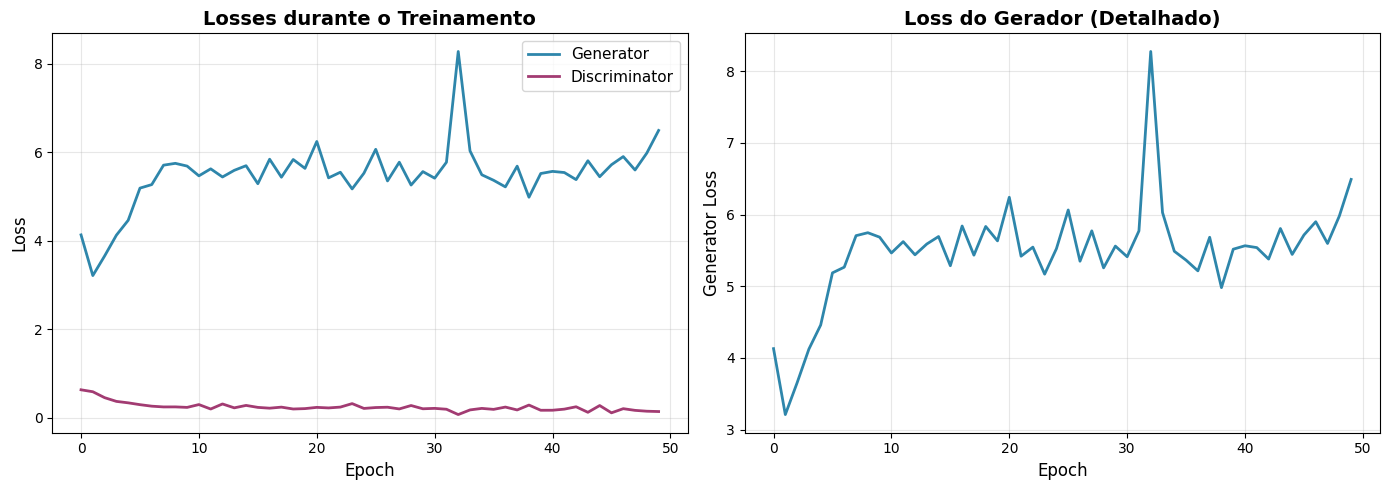


📊 Estatísticas de Treinamento:
   Generator Loss Final: 6.4895
   Discriminator Loss Final: 0.1377
   Generator Loss Inicial: 4.1294
   Discriminator Loss Inicial: 0.6290


In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(gen_losses, label='Generator', linewidth=2, color='#2E86AB')
plt.plot(dis_losses, label='Discriminator', linewidth=2, color='#A23B72')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Losses durante o Treinamento', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(gen_losses, label='Generator', linewidth=2, color='#2E86AB')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Generator Loss', fontsize=12)
plt.title('Loss do Gerador (Detalhado)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📊 Estatísticas de Treinamento:')
print(f'   Generator Loss Final: {gen_losses[-1]:.4f}')
print(f'   Discriminator Loss Final: {dis_losses[-1]:.4f}')
print(f'   Generator Loss Inicial: {gen_losses[0]:.4f}')
print(f'   Discriminator Loss Inicial: {dis_losses[0]:.4f}')

### 6.2 Imagens Geradas ao Longo do Treinamento

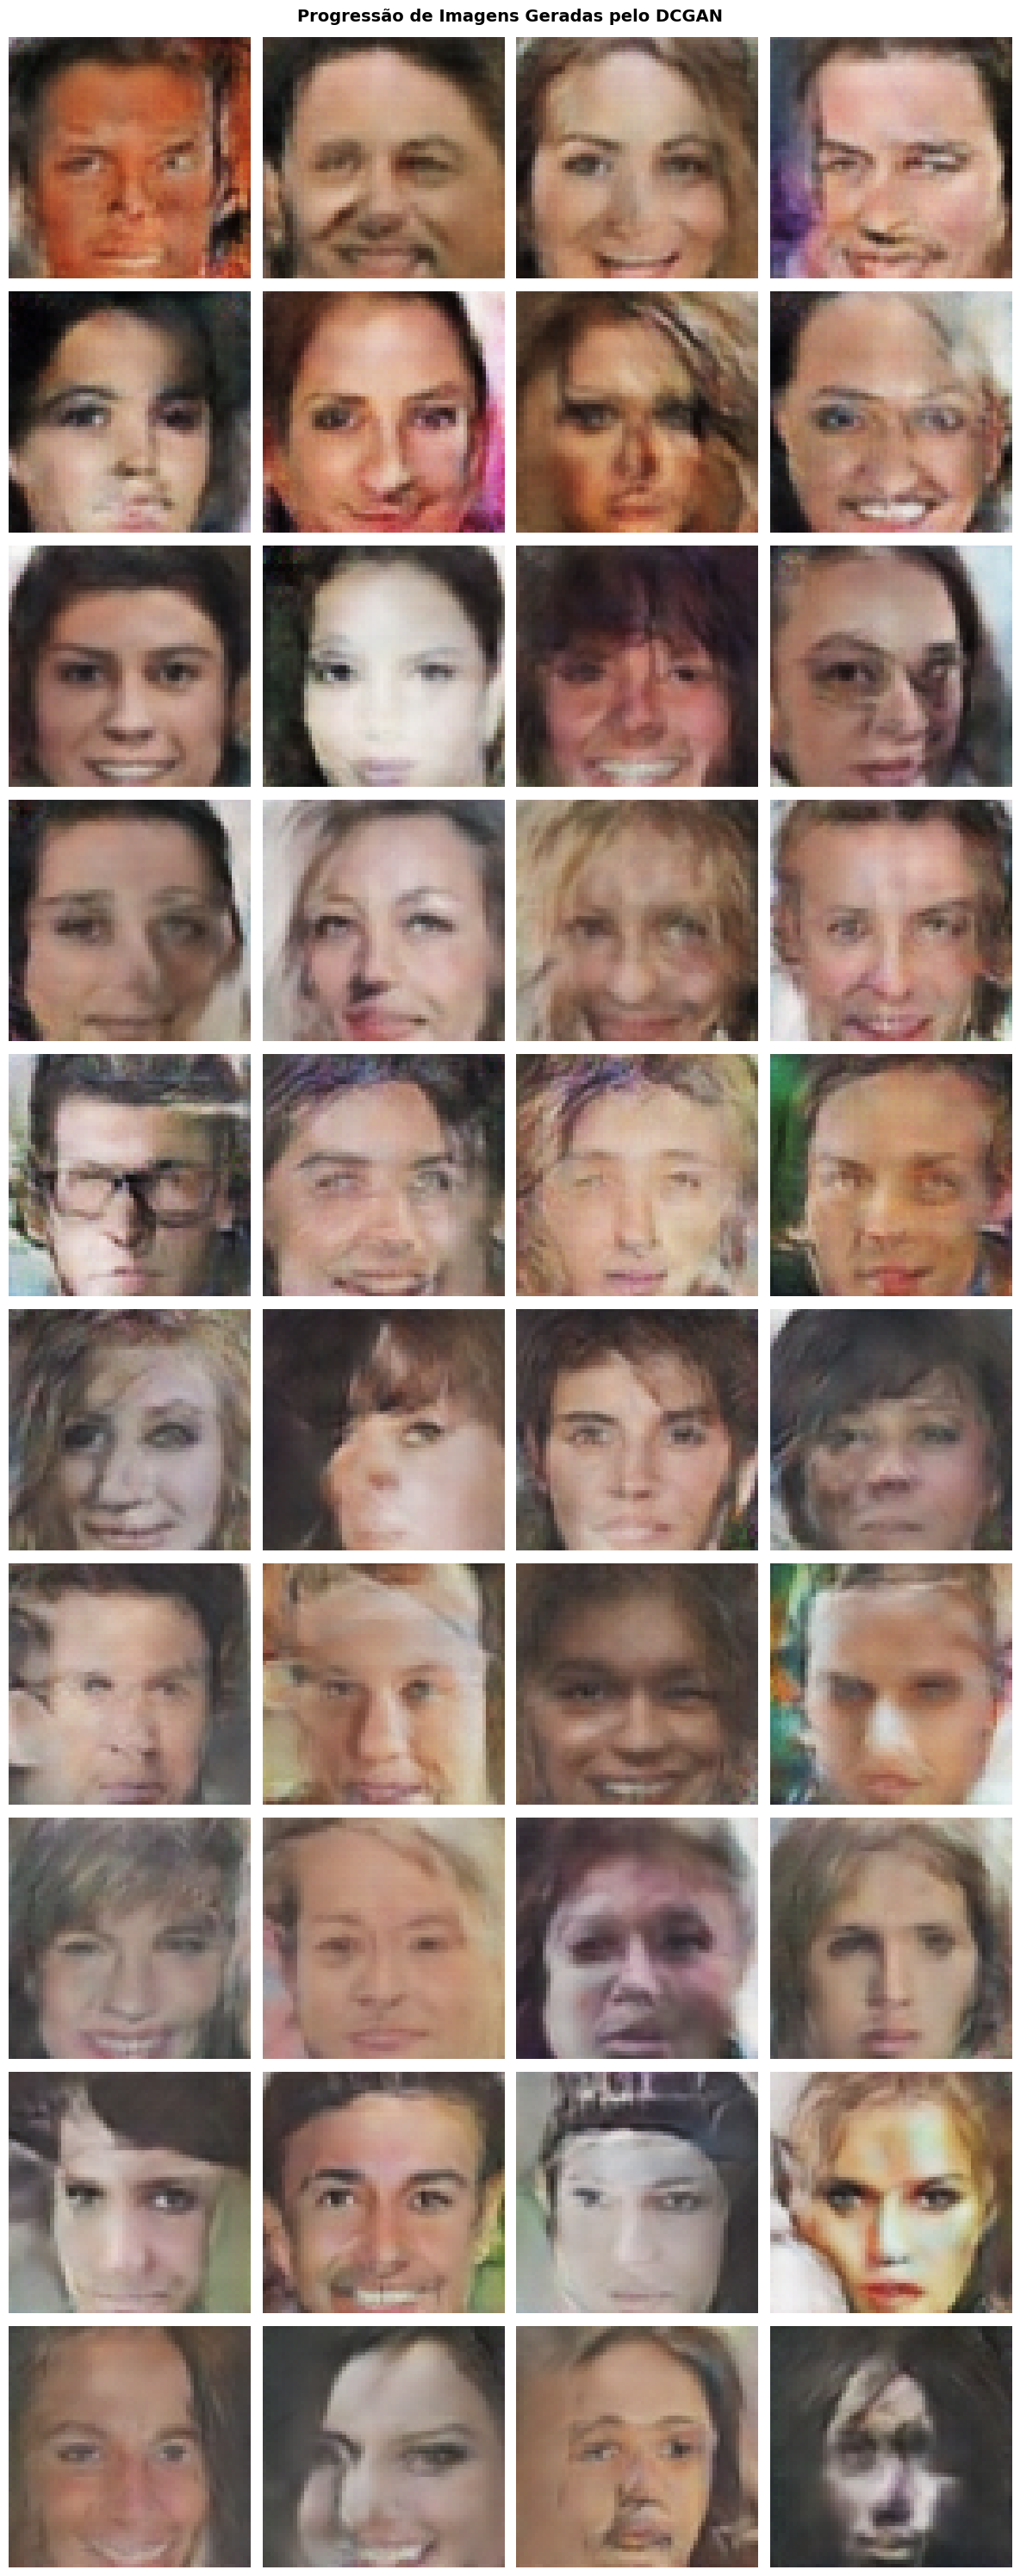

In [12]:
def display_generated_images(generated_list):
    """Exibir imagens geradas em diferentes pontos do treinamento."""
    
    num_checkpoints = len(generated_list)
    fig, axes = plt.subplots(num_checkpoints, 4, figsize=(12, num_checkpoints*3))
    
    if num_checkpoints == 1:
        axes = axes.reshape(1, -1)
    
    for i, images in enumerate(generated_list):
        for j in range(4):
            img = images[j]
            # Desnormalizar
            img = (img / 2) + 0.5
            img = np.transpose(img.numpy(), (1, 2, 0)).clip(0, 1)
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].set_ylabel(f'Epoch {(i+1)*5}', fontsize=12, fontweight='bold')
    
    plt.suptitle('Progressão de Imagens Geradas pelo DCGAN', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

display_generated_images(generated_images)

### 6.3 Imagens Finais Geradas

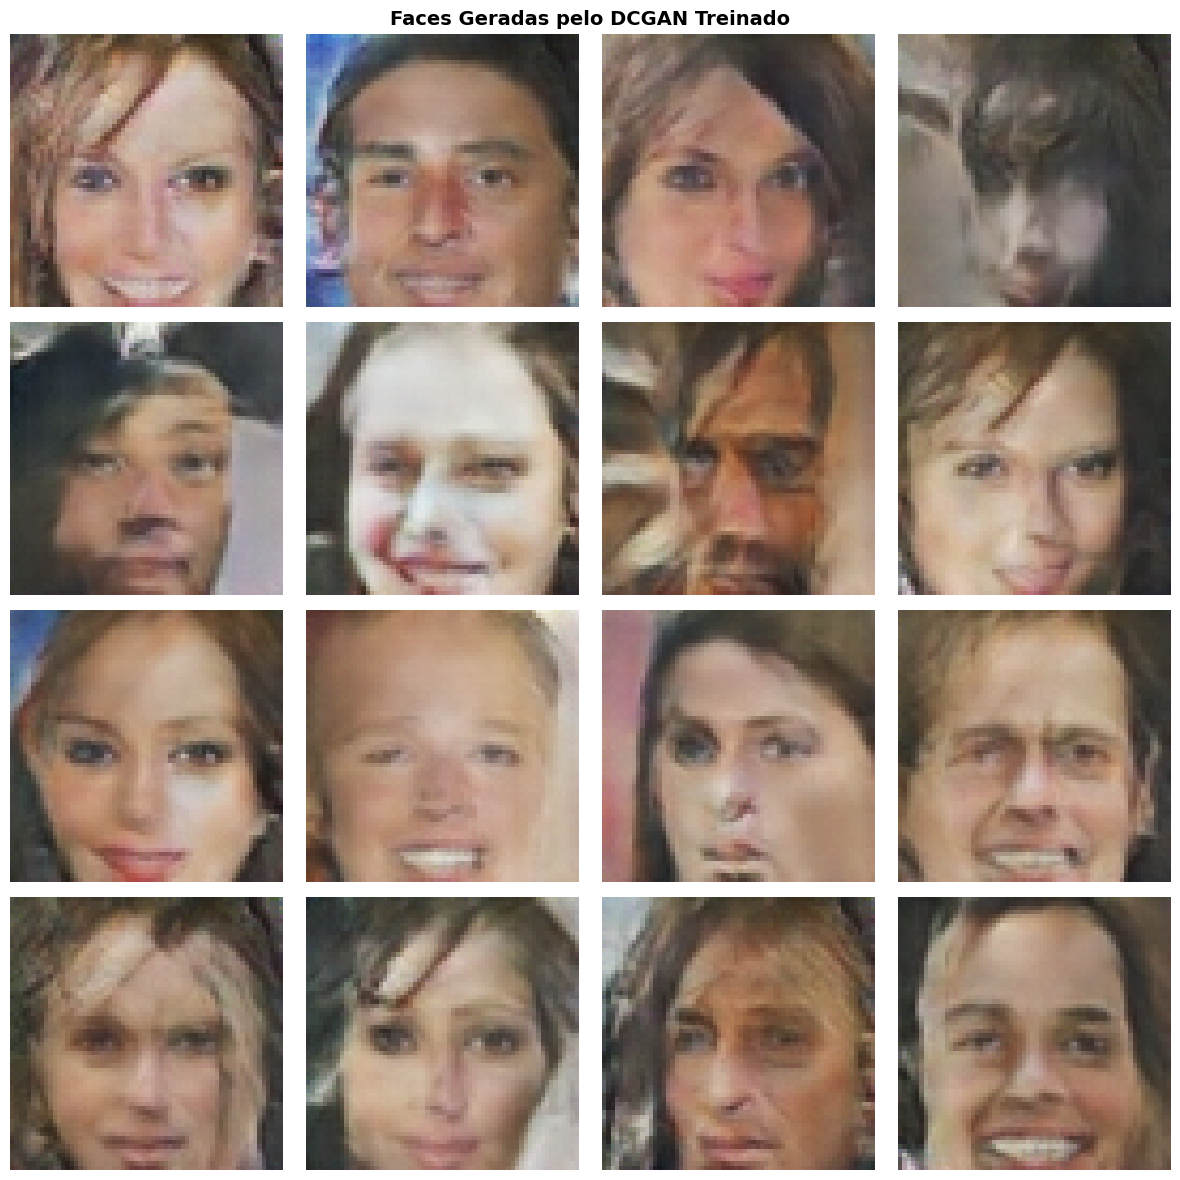

In [13]:
# Gerar imagens finais
with torch.no_grad():
    z = torch.randn(16, nz).to(device)
    final_images = gen(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for idx, ax in enumerate(axes.flat):
    img = final_images[idx]
    # Desnormalizar
    img = (img / 2) + 0.5
    img = np.transpose(img.numpy(), (1, 2, 0)).clip(0, 1)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Faces Geradas pelo DCGAN Treinado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Interpolação no Espaço Latente

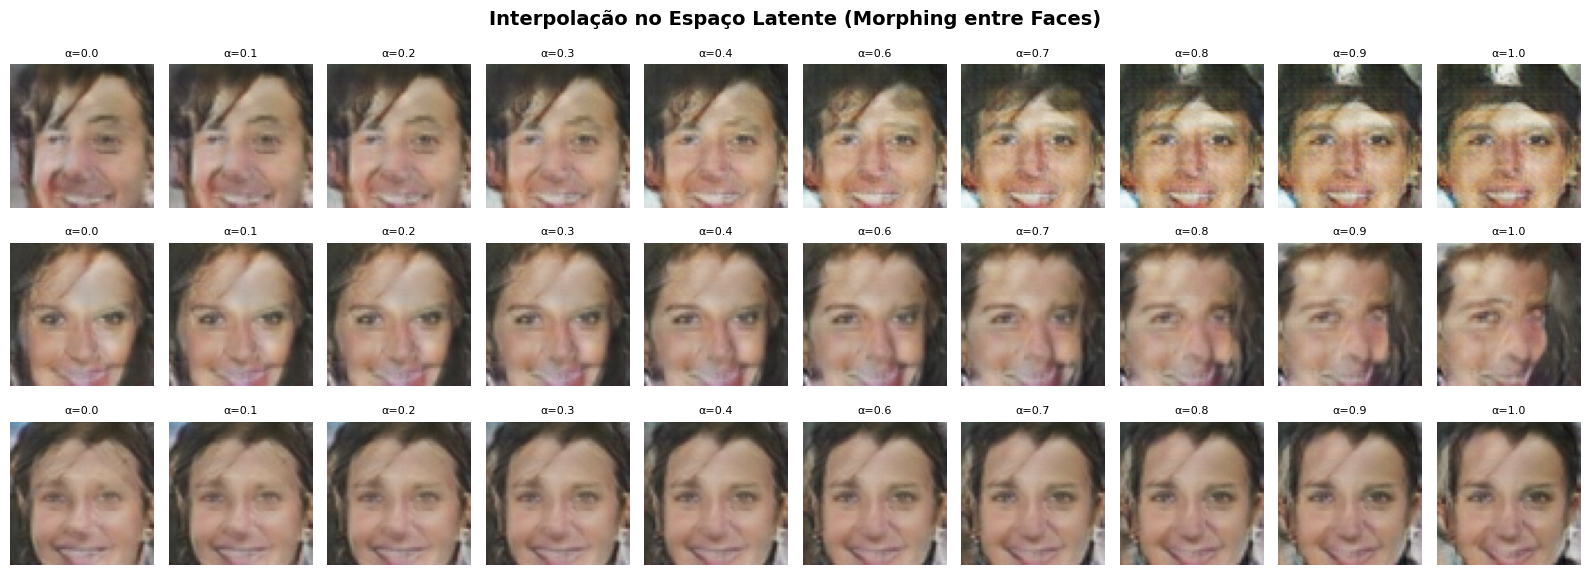

In [14]:
def interpolate_latent_space(z1, z2, steps=10):
    """
    Interpolar entre dois pontos no espaço latente.
    
    Args:
        z1, z2: vetores latentes iniciais
        steps: número de passos de interpolação
    
    Returns:
        Lista de imagens interpoladas
    """
    interpolated = []
    
    with torch.no_grad():
        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * z1 + alpha * z2
            img = gen(z)
            interpolated.append(img.cpu())
    
    return interpolated

# Criar múltiplas interpolações
num_interpolations = 3
fig, axes = plt.subplots(num_interpolations, 10, figsize=(16, num_interpolations*2))

for interp_idx in range(num_interpolations):
    z1 = torch.randn(1, nz).to(device)
    z2 = torch.randn(1, nz).to(device)
    
    interpolated_images = interpolate_latent_space(z1, z2, steps=10)
    
    for step_idx, img_tensor in enumerate(interpolated_images):
        ax = axes[interp_idx, step_idx]
        img = img_tensor[0]
        # Desnormalizar
        img = (img / 2) + 0.5
        img = np.transpose(img.numpy(), (1, 2, 0)).clip(0, 1)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'α={step_idx/9:.1f}', fontsize=8)

plt.suptitle('Interpolação no Espaço Latente (Morphing entre Faces)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Salvar Modelo

In [15]:
# Criar diretório para modelos
os.makedirs('./models', exist_ok=True)

# Salvar estado do gerador
torch.save(gen.state_dict(), './models/dcgan_generator.pth')
print('✅ Modelo do gerador salvo em: ./models/dcgan_generator.pth')

# Salvar estado do discriminador
torch.save(dis.state_dict(), './models/dcgan_discriminator.pth')
print('✅ Modelo do discriminador salvo em: ./models/dcgan_discriminator.pth')

# Salvar configuração dos modelos
config = {
    'nz': nz,
    'ngf': 64,
    'ndf': 64,
    'nc': 3,
    'img_size': img_size,
    'batch_size': batch_size,
    'learning_rate': learning_rate,
    'num_epochs': num_epochs
}

with open('./models/config.json', 'w') as f:
    json.dump(config, f, indent=4)

print('✅ Configuração salva em: ./models/config.json')

# Salvar histórico de losses
history = {
    'gen_losses': gen_losses,
    'dis_losses': dis_losses
}

with open('./models/training_history.json', 'w') as f:
    json.dump(history, f)

print('✅ Histórico de treinamento salvo em: ./models/training_history.json')

✅ Modelo do gerador salvo em: ./models/dcgan_generator.pth
✅ Modelo do discriminador salvo em: ./models/dcgan_discriminator.pth
✅ Configuração salva em: ./models/config.json
✅ Histórico de treinamento salvo em: ./models/training_history.json


## 9. Carregar e Usar Modelo Treinado

✅ Gerador carregado com sucesso!
   Configuração: {'nz': 100, 'ngf': 64, 'ndf': 64, 'nc': 3, 'img_size': 64, 'batch_size': 128, 'learning_rate': 0.0002, 'num_epochs': 50}


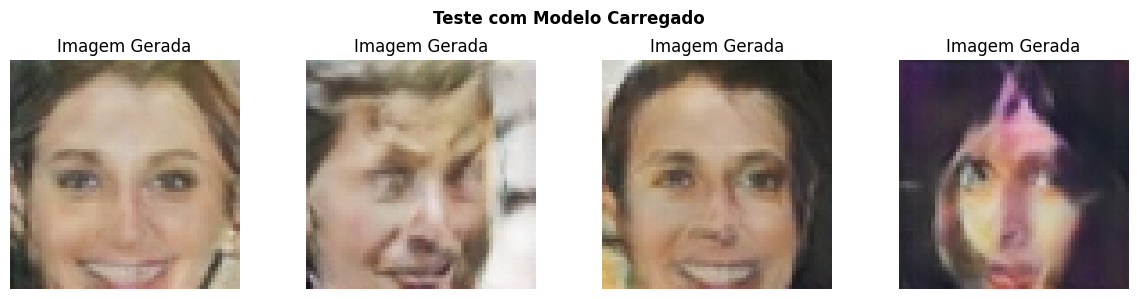

In [16]:
def load_generator(model_path='./models/dcgan_generator.pth', config_path='./models/config.json'):
    """
    Carregar um gerador treinado.
    
    Args:
        model_path: caminho para os pesos do modelo
        config_path: caminho para o arquivo de configuração
    
    Returns:
        Gerador carregado pronto para gerar imagens
    """
    # Carregar configuração
    with open(config_path, 'r') as f:
        config = json.load(f)
    
    # Criar modelo
    gen_loaded = Generator(
        nz=config['nz'],
        ngf=config['ngf'],
        nc=config['nc']
    ).to(device)
    
    # Carregar pesos
    gen_loaded.load_state_dict(torch.load(model_path, map_location=device))
    gen_loaded.eval()
    
    return gen_loaded, config

# Exemplo de uso (descomente quando tiver um modelo salvo)
try:
    gen_loaded, config_loaded = load_generator()
    print('✅ Gerador carregado com sucesso!')
    print(f'   Configuração: {config_loaded}')
    
    # Gerar algumas imagens com o modelo carregado
    with torch.no_grad():
        z = torch.randn(4, config_loaded['nz']).to(device)
        test_images = gen_loaded(z)
    
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for i, ax in enumerate(axes):
        img = test_images[i].cpu()
        img = (img / 2) + 0.5
        img = np.transpose(img.numpy(), (1, 2, 0)).clip(0, 1)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title('Imagem Gerada')
    
    plt.suptitle('Teste com Modelo Carregado', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('⚠️ Modelos ainda não foram salvos. Execute a célula anterior primeiro.')

## 10. Análise e Discussão

### 📊 Resultados Esperados:

- **Primeiros epochs**: Imagens aleatórias e confusas, muito ruído
- **Epochs intermediários**: Começam a aparecer padrões, rostos desfocados, estrutura básica visível
- **Últimos epochs**: Faces mais realistas, com características mais definidas, cores mais naturais

### 📈 Métricas de Desempenho:

- **Generator Loss**: Deve diminuir com o tempo (quer enganar o discriminador melhor)
- **Discriminator Loss**: Deve se estabilizar em um valor intermediário (equilíbrio entre real e fake)

### ⚙️ Dicas de Treinamento:

1. **Se o discriminador está muito bom** (loss → 0): 
   - Aumentar learning rate do gerador
   - Reduzir learning rate do discriminador
   - Aumentar batch size

2. **Se o gerador está muito bom** (discriminador fica confuso):
   - Aumentar learning rate do discriminador
   - Usar label smoothing (0.9 para real, 0.1 para fake)

3. **Instabilidade geral**:
   - Aumentar batch size (mais estável)
   - Usar spectral normalization
   - Tentar Wasserstein Loss com Gradient Penalty

### 🚀 Possíveis Melhorias Futuras:

- **Spectral Normalization**: Estabiliza o treinamento
- **Progressive Growing**: Começar com imagens pequenas e aumentar gradualmente
- **Wasserstein Loss**: Substitui BCE, mais estável (WGAN)
- **Gradient Penalty**: Força limite de Lipschitz (WGAN-GP)
- **Style-Based Architecture**: StyleGAN com estilo e conteúdo separados
- **Validação com FID/IS**: Métricas quantitativas de qualidade

### 🎯 Conclusão:

DCGAN é uma arquitetura poderosa para geração de imagens. Com este notebook, você tem um sistema completo para:
- Treinar GANs do zero
- Visualizar progressão de treinamento
- Gerar imagens realistas
- Interpolar no espaço latente
- Salvar e carregar modelos

Experimente ajustar os hiperparâmetros e explore as possibilidades!